# Preprocessing Function Tests

This notebook imports the functions from `preprocessing.py` and tests each one visually using images from the `samples/` folder.

In [26]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from preprocessing import (
    width_Img,
    height_Img,
    resize_image,
    image_to_grayscale,
    add_gaussian_blur,
    apply_canny_edge_detection,
    create_blank_image,
)

print(f"Default preprocessing size: {width_Img} x {height_Img}")

Default preprocessing size: 700 x 700


In [27]:
SAMPLES_DIR = Path("samples")
sample_paths = sorted(SAMPLES_DIR.glob("*.jpg")) + sorted(SAMPLES_DIR.glob("*.png"))

if not sample_paths:
    raise FileNotFoundError("No  images found in samples/. Add sample images before running this notebook.")

sample_paths

[PosixPath('samples/File0005.jpg'),
 PosixPath('samples/File0020.jpg'),
 PosixPath('samples/exam5_204_1.png'),
 PosixPath('samples/exam5_271_1.png'),
 PosixPath('samples/shapes_debug.png'),
 PosixPath('samples/synthetic_omr_sheet.png')]

In [28]:
def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))


def show_image(image, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)

    ax.set_title(title)
    ax.axis("off")
    return ax


def show_grid(items, columns=3, figsize=(14, 8)):
    rows = int(np.ceil(len(items) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (title, image) in zip(axes, items):
        show_image(image, title, ax=ax)

    for ax in axes[len(items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 1. Load Sample Images

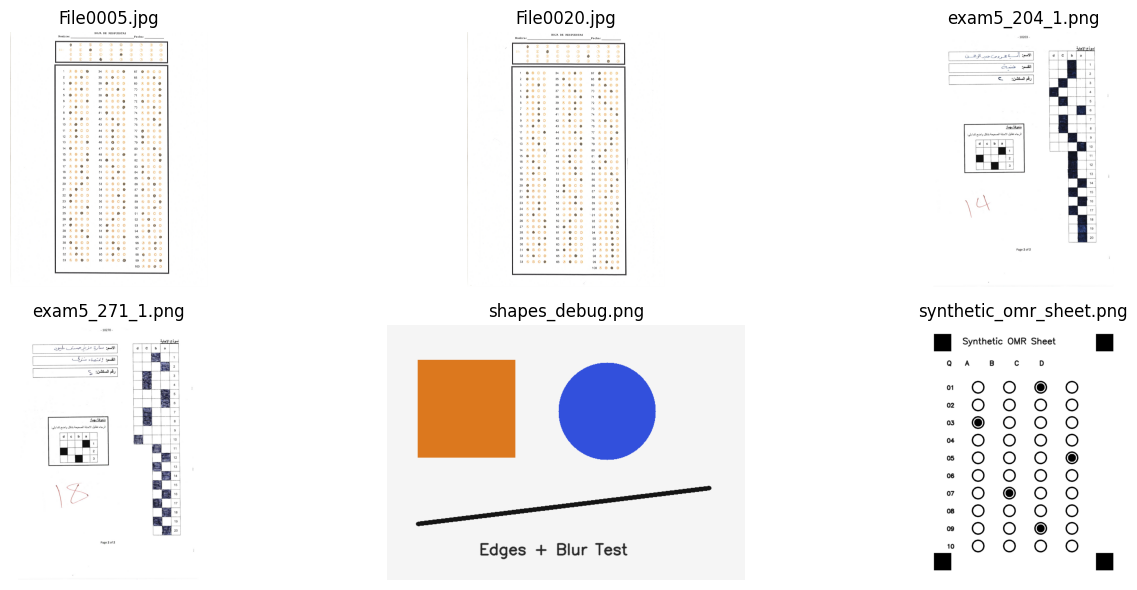

In [29]:
samples = {path.name: load_rgb(path) for path in sample_paths}

show_grid(
    [(name, image) for name, image in samples.items()],
    columns=3,
    figsize=(15, 6),
)

## 2. Test `resize_image`

Original shape: (4395, 3396, 3)
Resized shape: (700, 700, 3)


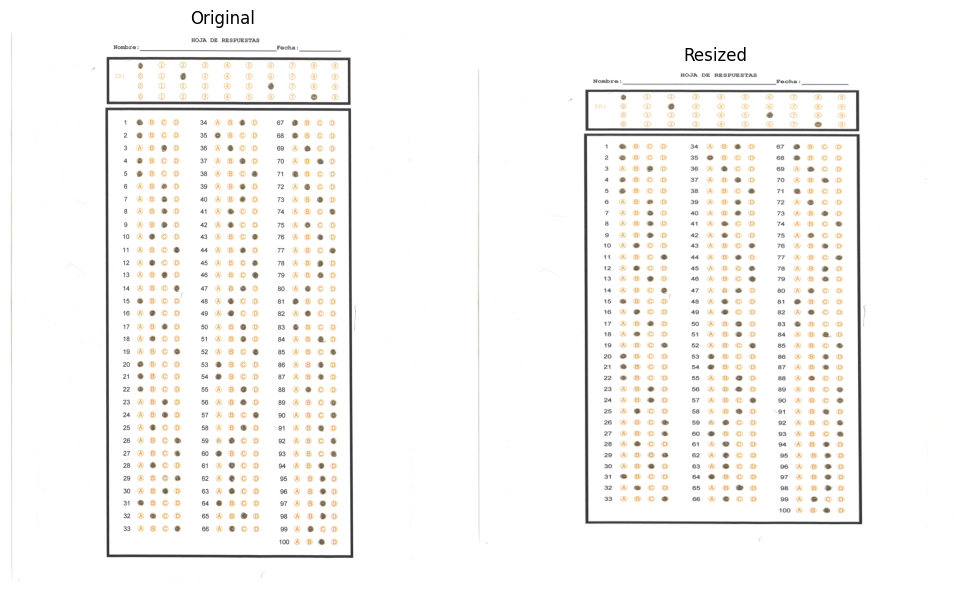

In [30]:
original = samples["File0020.jpg"]   # Change to your desired sample image
resized = resize_image(original)

print("Original shape:", original.shape)
print("Resized shape:", resized.shape)

show_grid([
    ("Original", original),
    ("Resized", resized),
], columns=2, figsize=(10, 6))

## 3. Test `image_to_grayscale`

Grayscale shape: (700, 700)
Grayscale dtype: uint8


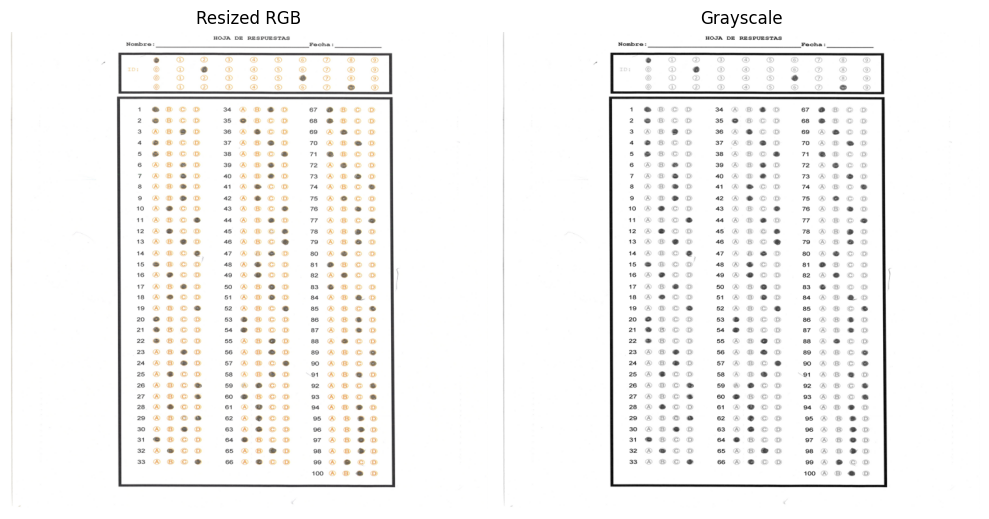

In [31]:
gray = image_to_grayscale(resized)

print("Grayscale shape:", gray.shape)
print("Grayscale dtype:", gray.dtype)

show_grid([
    ("Resized RGB", resized),
    ("Grayscale", gray),
], columns=2, figsize=(10, 6))

## 4. Test `add_gaussian_blur`

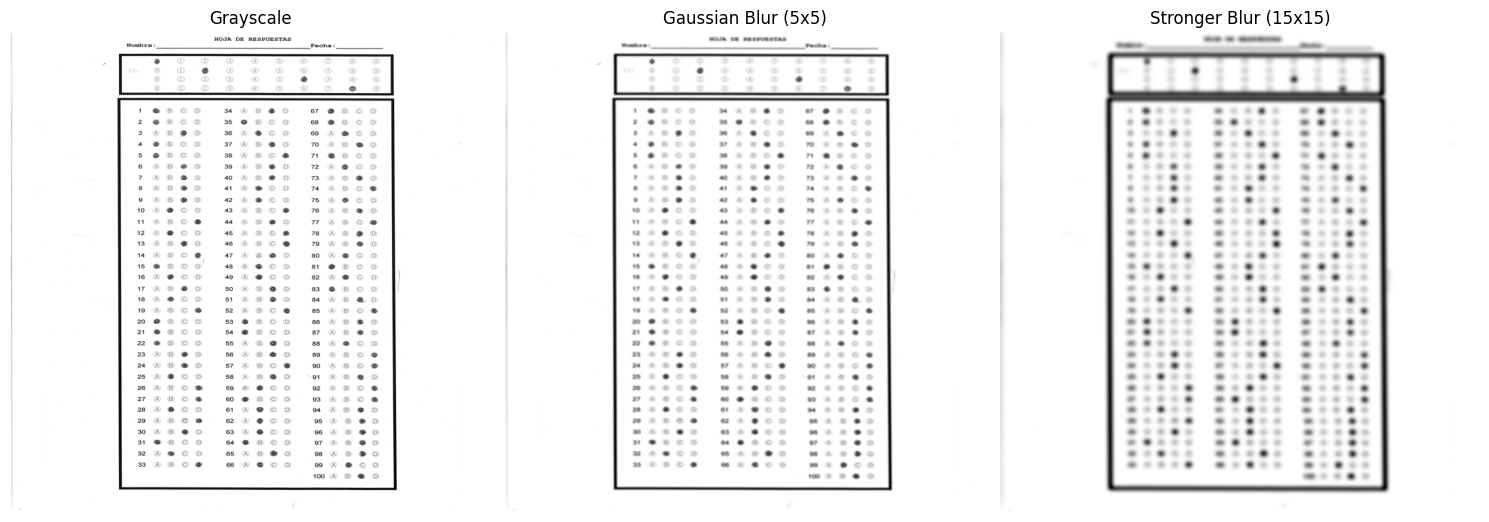

In [32]:
blurred = add_gaussian_blur(gray, kernel_size=(5, 5), sigma=1.0)
strong_blur = add_gaussian_blur(gray, kernel_size=(15, 15), sigma=3.0)

show_grid([
    ("Grayscale", gray),
    ("Gaussian Blur (5x5)", blurred),
    ("Stronger Blur (15x15)", strong_blur),
], columns=3, figsize=(15, 6))

## 5. Test `apply_canny_edge_detection`

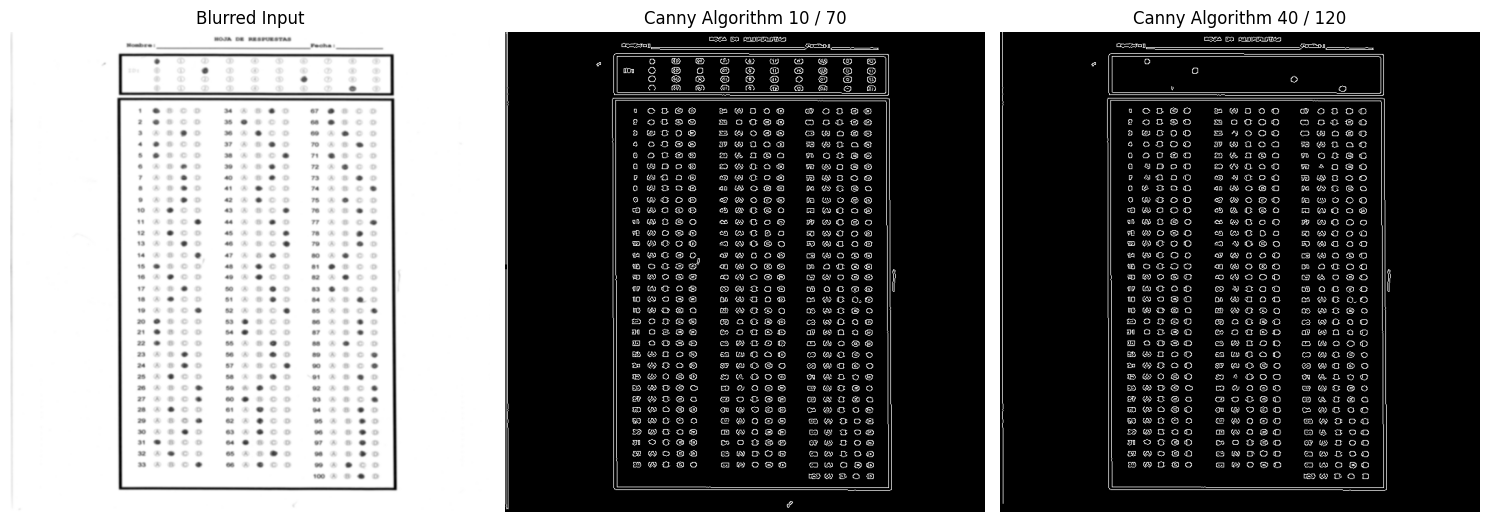

In [33]:
edges_default = apply_canny_edge_detection(blurred)
edges_stronger = apply_canny_edge_detection(blurred, low_threshold=40, high_threshold=120)

show_grid([
    ("Blurred Input", blurred),
    ("Canny Algorithm 10 / 70", edges_default),
    ("Canny Algorithm 40 / 120", edges_stronger),
], columns=3, figsize=(15, 6))

## 6. Test Full Preprocessing Pipeline

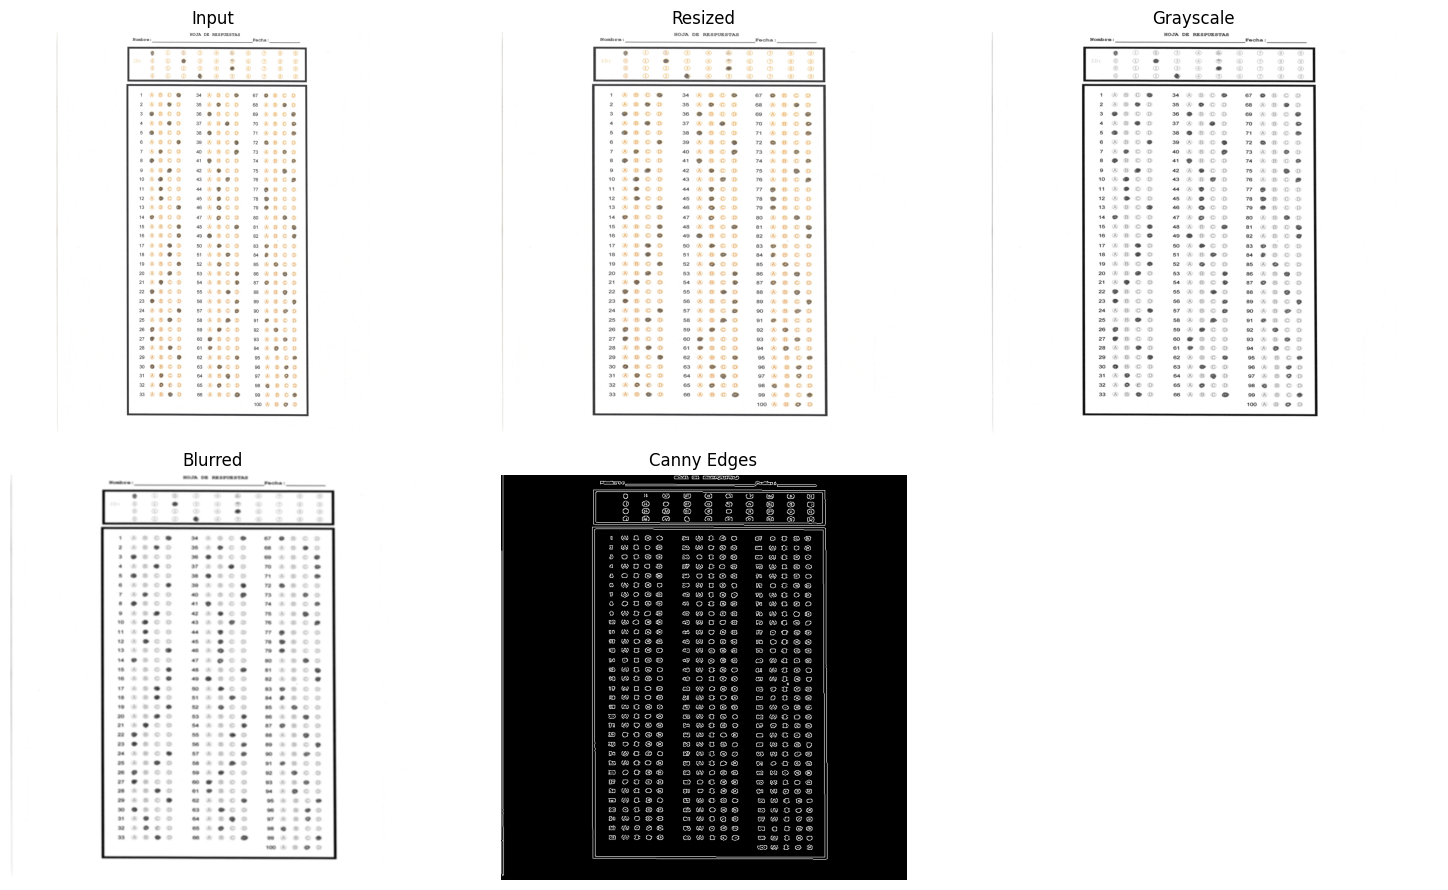

In [36]:
pipeline_image = samples["File0005.jpg"]

pipeline_resized = resize_image(pipeline_image)
pipeline_gray = image_to_grayscale(pipeline_resized)
pipeline_blur = add_gaussian_blur(pipeline_gray)
pipeline_edges = apply_canny_edge_detection(pipeline_blur)

show_grid([
    ("Input", pipeline_image),
    ("Resized", pipeline_resized),
    ("Grayscale", pipeline_gray),
    ("Blurred", pipeline_blur),
    ("Canny Edges", pipeline_edges),
], columns=3, figsize=(15, 9))

## 7. Test `create_blank_image`

Blank image shape: (700, 700, 3)
Unique pixel values: [0]


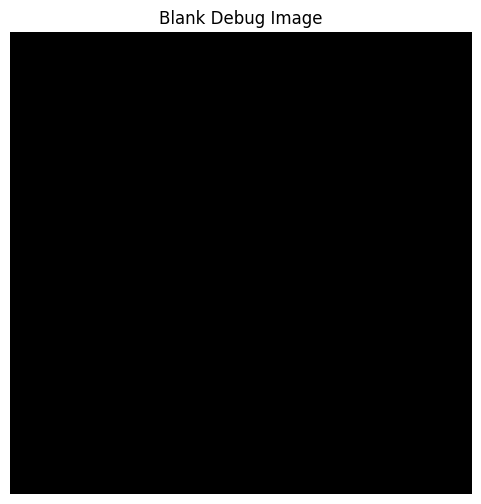

In [35]:
blank = create_blank_image()

print("Blank image shape:", blank.shape)
print("Unique pixel values:", np.unique(blank))

show_image(blank, "Blank Debug Image")
plt.show()